In [1]:
%load_ext autoreload

In [2]:
%autoreload 2

In [3]:
import numpy as np
import matplotlib.pyplot as plt

import sys

sys.path.append('//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses')
sys.path.append('//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/langevin-sindy')

In [6]:
svs = np.load('../data/vicreg_SVs.npy')
exp_var = np.load('../data/vicreg_ExpVar.npy')
pcs = np.load('../data/vicreg_PCs.npy')

Number of modes to explain 95% of variance:  47


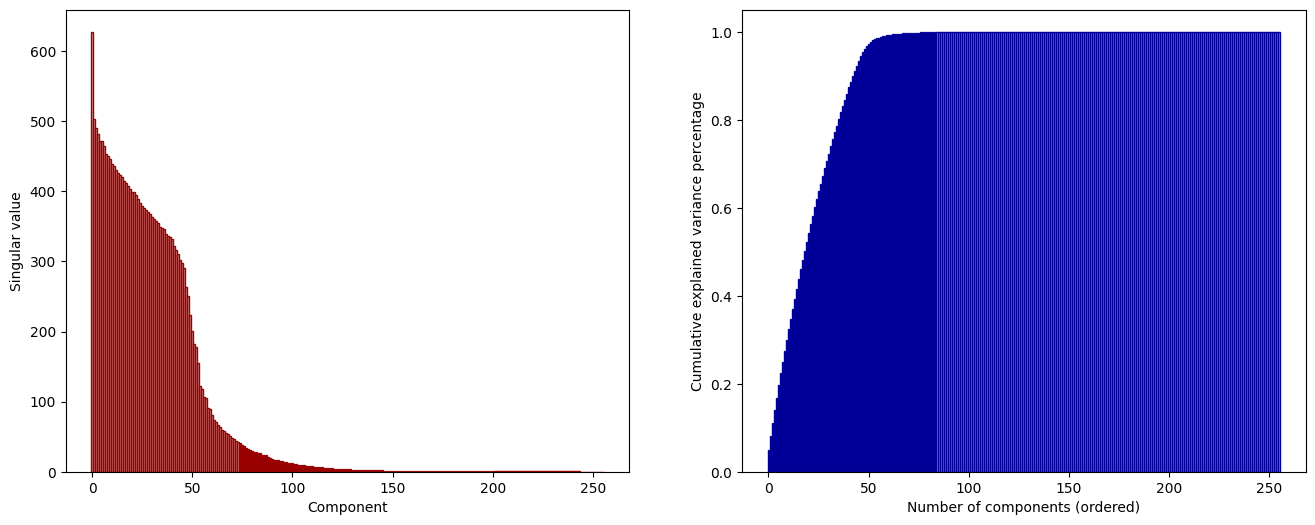

In [7]:
fig, ax = plt.subplots(1,2, figsize=(16,6))
m=len(svs)
ax[0].bar(np.arange(m),svs, color=(0.6,0,0.0,0.3),edgecolor=(0.6,0,0.0,1.0))
ax[0].set_xlabel("Component")
ax[0].set_ylabel("Singular value")

ax[1].bar(np.arange(m),np.cumsum(exp_var),color=(0.0,0,0.6,0.3),edgecolor=(0.0,0,0.6,1.0))
ax[1].set_xlabel("Number of components (ordered)")
ax[1].set_ylabel("Cumulative explained variance percentage")

num_modes_95 = np.where(np.cumsum(exp_var) > 0.95)[0].min()
print("Number of modes to explain 95% of variance: ", num_modes_95)

Text(0, 0.5, 'Cumulative explained variance percentage')

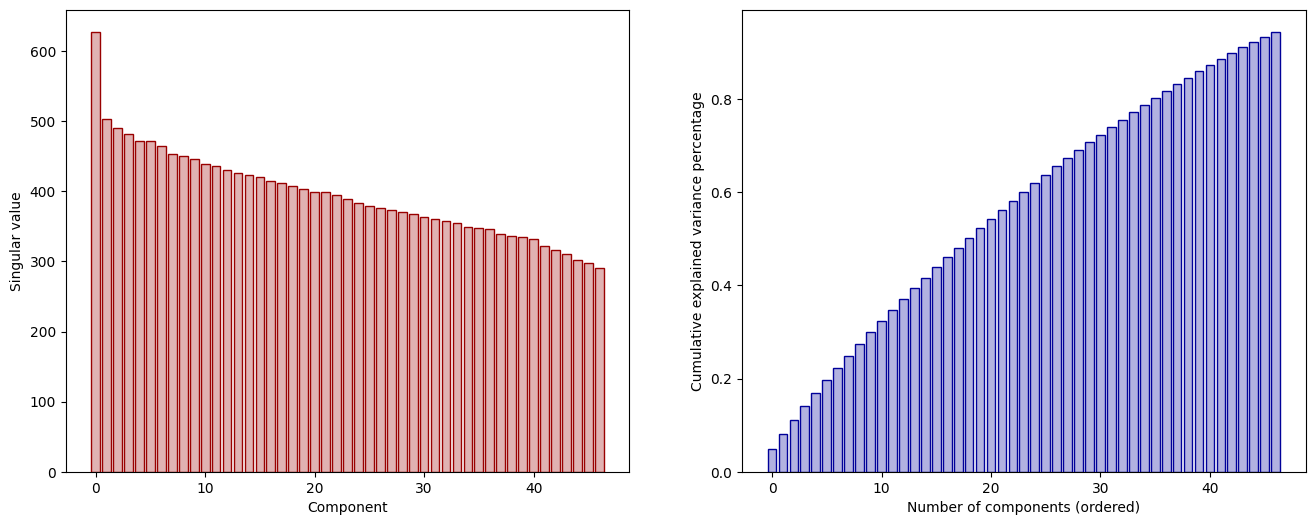

In [8]:
fig, ax = plt.subplots(1,2, figsize=(16,6))

ax[0].bar(np.arange(num_modes_95),svs[:num_modes_95], color=(0.6,0,0.0,0.3),edgecolor=(0.6,0,0.0,1.0))
ax[0].set_xlabel("Component")
ax[0].set_ylabel("Singular value")

ax[1].bar(np.arange(num_modes_95),np.cumsum(exp_var)[:num_modes_95],color=(0.0,0,0.6,0.3),edgecolor=(0.0,0,0.6,1.0))
ax[1].set_xlabel("Number of components (ordered)")
ax[1].set_ylabel("Cumulative explained variance percentage")

In [9]:
X_t = np.load('../data/vicreg_95pctVarPCs_all.npy') # preprocessed data: num_loc * num_timepoints * num_modes_95 array
X_pca = X_t.reshape((-1,num_modes_95))[:,:2] # truncated to top 2 modes

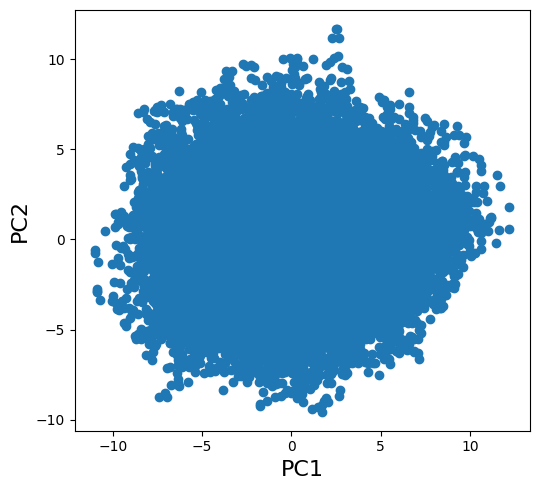

In [10]:
fig, ax = plt.subplots(1,1, figsize=(5.5,5))
sc_plt = ax.scatter(X_pca[:,0], X_pca[:,1]) 
ax.set_xlabel("PC1", fontsize=16)
ax.set_ylabel("PC2", fontsize=16)
plt.tight_layout()

In [11]:
X_t_high = np.load('../data/vicreg_95pctVarPCs_highFlow.npy')
X_t_low = np.load('../data/vicreg_95pctVarPCs_lowFlow.npy')

num_loc = X_t.shape[0]
num_t = X_t.shape[1]
t_change = (24*60 - 25)//5 # time point (frame number) at which to change from high to low flow occurs (25 minutes before 24 hours)

Text(0, 0.5, 'PC1')

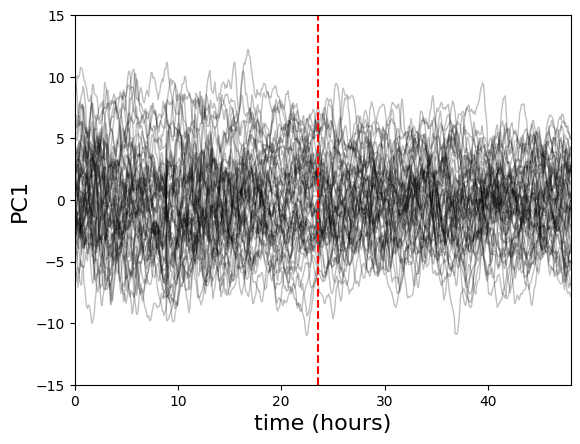

In [15]:
# plot top PCA mode vs time for each location at high flow
for i in range(num_loc):
    plt.plot(5*np.arange(num_t)/60,X_t[i,:,0],'k-',alpha=0.25,linewidth=1)
plt.xlim([0,(num_t)*5//60])
plt.ylim([-15,15])
plt.vlines(5*t_change/60,-15,15,color='r',linestyles='dashed')
#plt.vlines(530/60,-15,15,color='b',linestyles='dashed')
plt.xlabel("time (hours)", fontsize=16)
plt.ylabel("PC1", fontsize=16)

Text(0, 0.5, 'PC2')

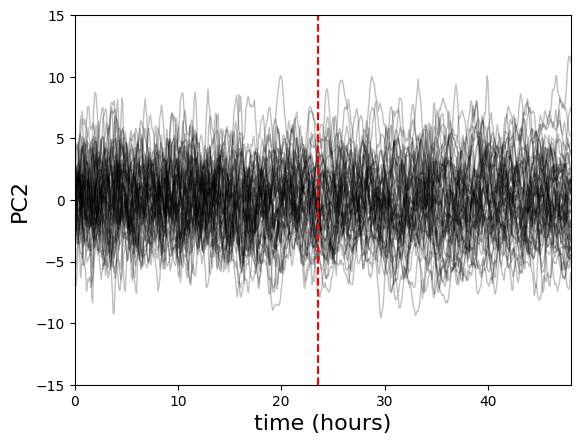

In [16]:
# plot PCA mode m vs time for each location at high flow
m=2

for i in range(num_loc):
    plt.plot(5*np.arange(num_t)/60,X_t[i,:,m-1],'k-',alpha=0.25,linewidth=1)
plt.xlim([0,(num_t)*5//60])
plt.ylim([-15,15])
plt.vlines(5*t_change/60,-15,15,color='r',linestyles='dashed')
#plt.vlines(530/60,-15,15,color='b',linestyles='dashed')
plt.xlabel("time (hours)", fontsize=16)
plt.ylabel("PC"+str(m), fontsize=16)

Text(0, 0.5, 'PC2')

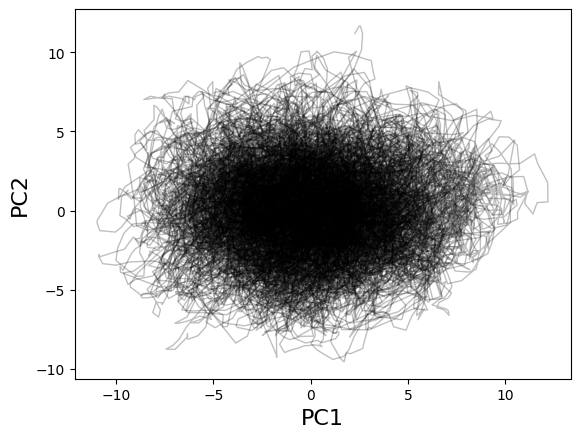

In [17]:
for i in range(num_loc):
    plt.plot(X_t[i,:,0],X_t[i,:,1],'k-',alpha=0.25,linewidth=1)
#plt.xlim([0,(num_t)*5])
plt.xlabel("PC1", fontsize=16)
plt.ylabel("PC2", fontsize=16)